In [3]:
# ==========================================
# SPAM EMAIL DETECTION USING MACHINE LEARNING
# ==========================================

# -------------------------------
# STEP 1 : Import Required Libraries
# -------------------------------

# pandas -> dataset handle karne ke liye
import pandas as pd

# train_test_split -> data ko training/testing me divide karne ke liye
from sklearn.model_selection import train_test_split

# CountVectorizer -> text ko numbers me convert karega
from sklearn.feature_extraction.text import CountVectorizer

# Naive Bayes Algorithm
from sklearn.naive_bayes import MultinomialNB

# Accuracy check karne ke liye
from sklearn.metrics import accuracy_score

# -------------------------------
# STEP 2 : Load Dataset
# -------------------------------

# Dataset read kar rahe hain
data = pd.read_csv("spam.csv", encoding='latin-1')

# First 5 rows dekhne ke liye
print("First 5 Rows:")
print(data.head())

# -------------------------------
# STEP 3 : Remove Unnecessary Columns
# -------------------------------

# Dataset me extra columns hoti hain
# Unhe remove karenge

data = data[['v1', 'v2']]

# Column names rename kar rahe hain
data.columns = ['label', 'message']

print("\nUpdated Dataset:")
print(data.head())

# -------------------------------
# STEP 4 : Convert Labels into Numbers
# -------------------------------

# ham = 0
# spam = 1

data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

print("\nConverted Labels:")
print(data.head())

# -------------------------------
# STEP 5 : Define Input and Output
# -------------------------------

# X = message text
X = data['message']

# y = spam or ham
y = data['label']

# -------------------------------
# STEP 6 : Convert Text into Numbers
# -------------------------------

# ML model text directly nahi samajhta
# Isliye CountVectorizer use karenge

vectorizer = CountVectorizer()

# Text ko numerical vectors me convert karna
X = vectorizer.fit_transform(X)

print("\nText Converted into Numerical Form!")

# -------------------------------
# STEP 7 : Train Test Split
# -------------------------------

# 80% training
# 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# -------------------------------
# STEP 8 : Create Model
# -------------------------------

# Naive Bayes model create kar rahe hain

model = MultinomialNB()

# -------------------------------
# STEP 9 : Train Model
# -------------------------------

# Model ko training data sikha rahe hain

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# -------------------------------
# STEP 10 : Make Predictions
# -------------------------------

# Testing data par prediction

y_pred = model.predict(X_test)

print("\nPredictions Completed!")

# -------------------------------
# STEP 11 : Check Accuracy
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy * 100)

# -------------------------------
# STEP 12 : Test with Custom Message
# -------------------------------

# New message manually check karenge

new_message = [
    "Congratulations! You won a free iPhone. Click now!"
]

# Message ko vector me convert karna
new_message_vector = vectorizer.transform(new_message)

# Prediction
prediction = model.predict(new_message_vector)

# Result print
if prediction[0] == 1:
    print("\nThis message is SPAM")
else:
    print("\nThis message is NOT SPAM")

First 5 Rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Updated Dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Converted Labels:


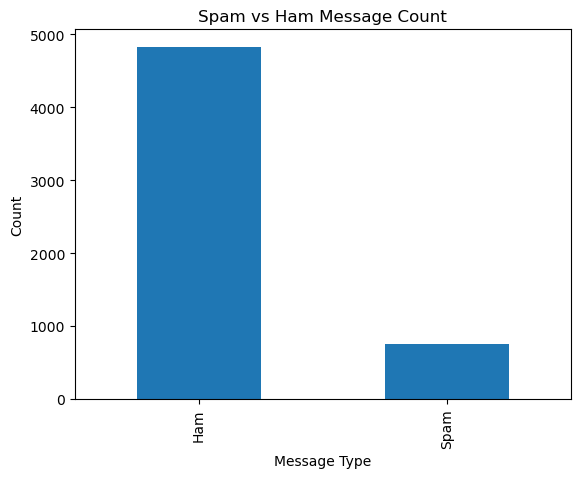

In [4]:
# --------------------------------
# DATA VISUALIZATION
# Spam vs Ham Count Graph
# --------------------------------

import matplotlib.pyplot as plt

# Labels count
data['label'].value_counts().plot(
    kind='bar'
)

# Title
plt.title("Spam vs Ham Message Count")

# X-axis labels
plt.xticks([0, 1], ['Ham', 'Spam'])

# Axis labels
plt.xlabel("Message Type")
plt.ylabel("Count")

# Show graph
plt.show()

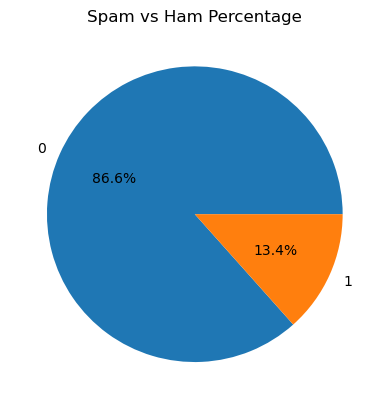

In [5]:
# --------------------------------
# Pie Chart Visualization
# --------------------------------

data['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Spam vs Ham Percentage")

plt.ylabel("")

plt.show()

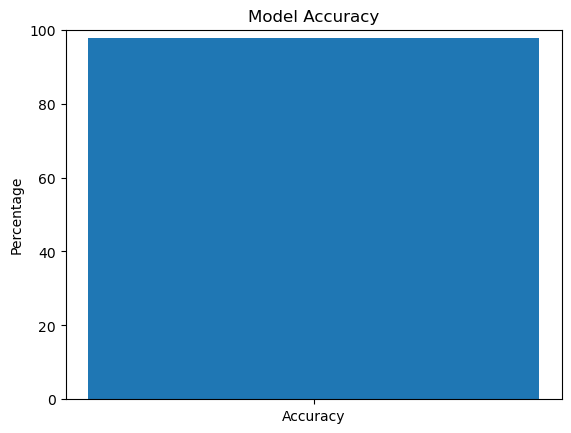

In [6]:
# --------------------------------
# Accuracy Visualization
# --------------------------------

accuracy_value = accuracy * 100

plt.bar(
    ['Accuracy'],
    [accuracy_value]
)

plt.ylim(0, 100)

plt.title("Model Accuracy")

plt.ylabel("Percentage")

plt.show()